# Ensemble of Ordinal Models

This notebook creates an ensemble combining four ordinal models:
1. **B0 Entropy-Ordinal**: EfficientNet-B0 with entropy filtering and ordinal loss
2. **B0 Entropy-Ordinal-Focal**: EfficientNet-B0 with entropy filtering, ordinal loss, and focal loss
3. **B0 Entropy-Ordinal-Weighted**: EfficientNet-B0 with entropy filtering, ordinal loss, and weighted loss
4. **B7 Entropy-Ordinal-Focal**: EfficientNet-B7 with entropy filtering, ordinal loss, and focal loss

All models use ordinal regression with 5 output thresholds for ISUP grading.

In [1]:
from torchvision.models import efficientnet_b0, efficientnet_b7, efficientnet_b3
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B7_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../../..')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [2]:
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # Ordinal thresholds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('logs', exist_ok=True)

Using device: cuda


## Ordinal Prediction Utilities

In [3]:
def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(logits)
    
    # Sum probabilities > 0.5 to get predicted grade
    predictions = (probs > 0.5).sum(dim=1)
    
    return predictions

print("Ordinal prediction utilities loaded")

Ordinal prediction utilities loaded


## Load Pre-trained Ordinal Models

In [4]:
from torchvision.models import EfficientNet_B3_Weights

# Model 1: B0 Entropy-Ordinal
print("Loading Model 1: B3 Entropy-Ordinal...")
load_model_1 = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
model_1 = EfficientNetApi(model=load_model_1, output_dimensions=output_classes, dropout_rate=0.6)
model_1.load_state_dict(torch.load("models/b3-entropy-ordinal-focal.pth", weights_only=True))
model_1 = model_1.to(device)
model_1.eval()
print("✓ Loaded B3 Entropy-Ordinal")

# Model 2: B0 Entropy-Ordinal-Focal
print("\nLoading Model 2: B0 Entropy-Ordinal-Focal...")
load_model_2 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_2 = EfficientNetApi(model=load_model_2, output_dimensions=output_classes, dropout_rate=0.6)
model_2.load_state_dict(torch.load("models/b0-entropy-ordinal-focal.pth", weights_only=True))
model_2 = model_2.to(device)
model_2.eval()
print("✓ Loaded B0 Entropy-Ordinal-Focal")

# Model 3: B0 Entropy-Ordinal-Weighted
# print("\nLoading Model 3: B0 Entropy-Ordinal-Weighted...")
# load_model_3 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
# model_3 = EfficientNetApi(model=load_model_3, output_dimensions=output_classes, dropout_rate=0.6)
# model_3.load_state_dict(torch.load("models/b0-entropy-ordinal-weighted.pth", weights_only=True))
# model_3 = model_3.to(device)
# model_3.eval()
# print("✓ Loaded B0 Entropy-Ordinal-Weighted")

# Model 4: B7 Entropy-Ordinal-Focal
print("\nLoading Model 4: B7 Entropy-Ordinal-Focal...")
load_model_4 = efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)
model_4 = EfficientNetApi(model=load_model_4, output_dimensions=output_classes, dropout_rate=0.6)
model_4.load_state_dict(torch.load("models/b7-entropy-ordinal-focal.pth", weights_only=True))
model_4 = model_4.to(device)
model_4.eval()
print("✓ Loaded B7 Entropy-Ordinal-Focal")

# Collect all models
models_list = [model_1, model_2, model_4]
model_names = [
    "B3-Entropy-Ordinal-Focal",
    "B0-Entropy-Ordinal-Focal",
    # "B0-Entropy-Ordinal-Weighted",
    "B7-Entropy-Ordinal-Focal"
]

print(f"\n{'='*80}")
print(f"Total models loaded: {len(models_list)}")
print(f"{'='*80}")

Loading Model 1: B3 Entropy-Ordinal...
✓ Loaded B3 Entropy-Ordinal

Loading Model 2: B0 Entropy-Ordinal-Focal...
✓ Loaded B0 Entropy-Ordinal-Focal

Loading Model 4: B7 Entropy-Ordinal-Focal...
✓ Loaded B7 Entropy-Ordinal-Focal

Total models loaded: 3


## Load Test Dataset

In [5]:
# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_test = remove_nonexistent_images(df_test, images_dir)

print(f"Test samples: {len(df_test)}")

# Create test dataset and dataloader
test_dataset = PandasDataset(images_dir, df_test, transforms=None, format="png")
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Test batches: {len(test_loader)}")

Test samples: 1590
Test batches: 530


## Ensemble Class for Ordinal Models

In [6]:
class OrdinalEnsemble(nn.Module):
    """
    Ensemble class for ordinal regression models.
    
    Supports multiple ensemble methods:
    - mean: Average of probabilities
    - weighted_mean: Weighted average of probabilities
    - max: Maximum of probabilities
    - majority_vote: Hard voting on predicted classes
    """
    def __init__(self, models, method='mean', weights=None):
        super(OrdinalEnsemble, self).__init__()
        self.models = nn.ModuleList(models)
        self.method = method
        self.weights = weights
        
        if method == 'weighted_mean' and weights is not None:
            # Normalize weights
            self.weights = torch.tensor(weights, dtype=torch.float32)
            self.weights = self.weights / self.weights.sum()
            print(f"Using normalized weights: {self.weights.tolist()}")
    
    def forward(self, x):
        """
        Args:
            x: Input batch
        
        Returns:
            Ensemble predictions (logits or probabilities depending on method)
        """
        # Get predictions from all models
        all_logits = []
        for model in self.models:
            with torch.no_grad():
                logits = model(x)
                all_logits.append(logits)
        
        # Stack all predictions: (num_models, batch_size, num_classes)
        all_logits = torch.stack(all_logits)
        
        if self.method == 'mean':
            # Average probabilities
            all_probs = torch.sigmoid(all_logits)
            ensemble_probs = all_probs.mean(dim=0)
            # Convert back to logits for consistency
            ensemble_logits = torch.logit(ensemble_probs.clamp(1e-7, 1-1e-7))
            return ensemble_logits
        
        elif self.method == 'weighted_mean':
            # Weighted average of probabilities
            all_probs = torch.sigmoid(all_logits)
            weights = self.weights.to(all_probs.device).view(-1, 1, 1)
            ensemble_probs = (all_probs * weights).sum(dim=0)
            # Convert back to logits
            ensemble_logits = torch.logit(ensemble_probs.clamp(1e-7, 1-1e-7))
            return ensemble_logits
        
        elif self.method == 'max':
            # Maximum of probabilities
            all_probs = torch.sigmoid(all_logits)
            ensemble_probs = all_probs.max(dim=0)[0]
            ensemble_logits = torch.logit(ensemble_probs.clamp(1e-7, 1-1e-7))
            return ensemble_logits
        
        elif self.method == 'majority_vote':
            # Hard voting on predicted classes
            all_preds = []
            for logits in all_logits:
                preds = decode_ordinal_predictions(logits)
                all_preds.append(preds)
            
            all_preds = torch.stack(all_preds)  # (num_models, batch_size)
            
            # Get mode (most common prediction)
            ensemble_preds = all_preds.mode(dim=0)[0]
            
            # Convert back to ordinal logits (for compatibility)
            batch_size = ensemble_preds.shape[0]
            ensemble_logits = torch.zeros(batch_size, 5, device=x.device)
            for i in range(batch_size):
                grade = ensemble_preds[i].item()
                if grade > 0:
                    ensemble_logits[i, :int(grade)] = 10.0  # High logit for 1
                if grade < 5:
                    ensemble_logits[i, int(grade):] = -10.0  # Low logit for 0
            
            return ensemble_logits
        
        else:
            raise ValueError(f"Unknown ensemble method: {self.method}")

print("OrdinalEnsemble class defined")

OrdinalEnsemble class defined


## Evaluation Function

In [7]:
def evaluate_model(model, dataloader, device, model_name="Model"):
    """
    Evaluate a model on the test set.
    
    Args:
        model: Model to evaluate
        dataloader: Test data loader
        device: Device to run on
        model_name: Name for progress bar
    
    Returns:
        Dictionary with predictions, targets, and metrics
    """
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in tqdm(dataloader, desc=f"Evaluating {model_name}"):
            batch_data = batch_data.to(device)
            
            # Forward pass
            logits = model(batch_data)
            
            # Decode ordinal predictions
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets to class labels
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
    
    # Concatenate results
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'predictions': all_preds,
        'targets': all_targets,
        'accuracy': accuracy,
        'kappa': kappa,
        'f1': f1,
        'recall': recall,
        'precision': precision
    }

def print_metrics(metrics, model_name):
    """
    Print evaluation metrics.
    """
    print(f"\n{'='*80}")
    print(f"{model_name} - TEST RESULTS")
    print(f"{'='*80}")
    print(f"Accuracy:  {metrics['accuracy']*100:.2f}%")
    print(f"Kappa:     {metrics['kappa']:.4f}")
    print(f"F1:        {metrics['f1']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"{'='*80}")

print("Evaluation functions defined")

Evaluation functions defined


## Evaluate Individual Models

In [8]:
print("\n" + "="*80)
print("INDIVIDUAL MODEL PERFORMANCE")
print("="*80)

individual_results = {}

for i, (model, name) in enumerate(zip(models_list, model_names)):
    print(f"\n{i+1}. {name}")
    metrics = evaluate_model(model, test_loader, device, name)
    individual_results[name] = metrics
    print_metrics(metrics, name)


INDIVIDUAL MODEL PERFORMANCE

1. B3-Entropy-Ordinal-Focal


Evaluating B3-Entropy-Ordinal-Focal: 100%|██████████| 530/530 [02:42<00:00,  3.27it/s]



B3-Entropy-Ordinal-Focal - TEST RESULTS
Accuracy:  65.97%
Kappa:     0.8484
F1:        0.6188
Recall:    0.6169
Precision: 0.6243

2. B0-Entropy-Ordinal-Focal


Evaluating B0-Entropy-Ordinal-Focal: 100%|██████████| 530/530 [01:33<00:00,  5.67it/s]



B0-Entropy-Ordinal-Focal - TEST RESULTS
Accuracy:  66.04%
Kappa:     0.8570
F1:        0.6124
Recall:    0.6123
Precision: 0.6282

3. B7-Entropy-Ordinal-Focal


Evaluating B7-Entropy-Ordinal-Focal: 100%|██████████| 530/530 [07:43<00:00,  1.14it/s]


B7-Entropy-Ordinal-Focal - TEST RESULTS
Accuracy:  60.25%
Kappa:     0.8440
F1:        0.5564
Recall:    0.5550
Precision: 0.5610


## Create and Evaluate Ensemble Models

### 1. Mean Ensemble (Simple Average)

In [9]:
print("\n" + "="*80)
print("ENSEMBLE: MEAN (Simple Average of Probabilities)")
print("="*80)

ensemble_mean = OrdinalEnsemble(models_list, method='mean')
ensemble_mean = ensemble_mean.to(device)

metrics_mean = evaluate_model(ensemble_mean, test_loader, device, "Ensemble-Mean")
print_metrics(metrics_mean, "Ensemble-Mean")


ENSEMBLE: MEAN (Simple Average of Probabilities)


Evaluating Ensemble-Mean: 100%|██████████| 530/530 [10:55<00:00,  1.24s/it]


Ensemble-Mean - TEST RESULTS
Accuracy:  69.81%
Kappa:     0.8800
F1:        0.6539
Recall:    0.6527
Precision: 0.6585


### 2. Weighted Mean Ensemble

Weights based on model complexity and expected performance:
- B0-Entropy-Ordinal: 0.20
- B0-Entropy-Ordinal-Focal: 0.30
- B0-Entropy-Ordinal-Weighted: 0.20
- B7-Entropy-Ordinal-Focal: 0.30 (higher weight for larger model)

In [10]:
print("\n" + "="*80)
print("ENSEMBLE: WEIGHTED MEAN")
print("="*80)

# Define weights
weights = [0.3, 0.5, 0.3]
print(f"Weights: {dict(zip(model_names, weights))}")

ensemble_weighted = OrdinalEnsemble(models_list, method='weighted_mean', weights=weights)
ensemble_weighted = ensemble_weighted.to(device)

metrics_weighted = evaluate_model(ensemble_weighted, test_loader, device, "Ensemble-Weighted")
print_metrics(metrics_weighted, "Ensemble-Weighted")


ENSEMBLE: WEIGHTED MEAN
Weights: {'B3-Entropy-Ordinal-Focal': 0.3, 'B0-Entropy-Ordinal-Focal': 0.5, 'B7-Entropy-Ordinal-Focal': 0.3}
Using normalized weights: [0.27272728085517883, 0.45454543828964233, 0.27272728085517883]


Evaluating Ensemble-Weighted: 100%|██████████| 530/530 [09:57<00:00,  1.13s/it]


Ensemble-Weighted - TEST RESULTS
Accuracy:  69.25%
Kappa:     0.8792
F1:        0.6468
Recall:    0.6455
Precision: 0.6528


### 3. Max Ensemble (Maximum Probability)

In [11]:
print("\n" + "="*80)
print("ENSEMBLE: MAX (Maximum of Probabilities)")
print("="*80)

ensemble_max = OrdinalEnsemble(models_list, method='max')
ensemble_max = ensemble_max.to(device)

metrics_max = evaluate_model(ensemble_max, test_loader, device, "Ensemble-Max")
print_metrics(metrics_max, "Ensemble-Max")


ENSEMBLE: MAX (Maximum of Probabilities)


Evaluating Ensemble-Max: 100%|██████████| 530/530 [10:06<00:00,  1.14s/it]


Ensemble-Max - TEST RESULTS
Accuracy:  58.30%
Kappa:     0.8396
F1:        0.5583
Recall:    0.5709
Precision: 0.5625


### 4. Majority Vote Ensemble (Hard Voting)

In [12]:
print("\n" + "="*80)
print("ENSEMBLE: MAJORITY VOTE (Hard Voting)")
print("="*80)

ensemble_vote = OrdinalEnsemble(models_list, method='majority_vote')
ensemble_vote = ensemble_vote.to(device)

metrics_vote = evaluate_model(ensemble_vote, test_loader, device, "Ensemble-Vote")
print_metrics(metrics_vote, "Ensemble-Vote")


ENSEMBLE: MAJORITY VOTE (Hard Voting)


Evaluating Ensemble-Vote: 100%|██████████| 530/530 [10:06<00:00,  1.14s/it]


Ensemble-Vote - TEST RESULTS
Accuracy:  69.25%
Kappa:     0.8598
F1:        0.6459
Recall:    0.6424
Precision: 0.6534


## Results Comparison

In [13]:
# Collect all results
all_results = {
    **individual_results,
    'Ensemble-Mean': metrics_mean,
    'Ensemble-Weighted': metrics_weighted,
    'Ensemble-Max': metrics_max,
    'Ensemble-Vote': metrics_vote
}

# Create comparison table
print("\n" + "="*100)
print("COMPLETE RESULTS COMPARISON")
print("="*100)
print(f"{'Model':<40} {'Accuracy':>12} {'Kappa':>10} {'F1':>10} {'Recall':>10} {'Precision':>10}")
print("-"*100)

# Sort by kappa score
sorted_results = sorted(all_results.items(), key=lambda x: x[1]['kappa'], reverse=True)

for name, metrics in sorted_results:
    print(f"{name:<40} {metrics['accuracy']*100:>11.2f}% {metrics['kappa']:>10.4f} {metrics['f1']:>10.4f} {metrics['recall']:>10.4f} {metrics['precision']:>10.4f}")

print("="*100)

# Find best model
best_model = sorted_results[0][0]
best_kappa = sorted_results[0][1]['kappa']
print(f"\n✓ Best model: {best_model} (Kappa: {best_kappa:.4f})")


COMPLETE RESULTS COMPARISON
Model                                        Accuracy      Kappa         F1     Recall  Precision
----------------------------------------------------------------------------------------------------
Ensemble-Mean                                  69.81%     0.8800     0.6539     0.6527     0.6585
Ensemble-Weighted                              69.25%     0.8792     0.6468     0.6455     0.6528
Ensemble-Vote                                  69.25%     0.8598     0.6459     0.6424     0.6534
B0-Entropy-Ordinal-Focal                       66.04%     0.8570     0.6124     0.6123     0.6282
B3-Entropy-Ordinal-Focal                       65.97%     0.8484     0.6188     0.6169     0.6243
B7-Entropy-Ordinal-Focal                       60.25%     0.8440     0.5564     0.5550     0.5610
Ensemble-Max                                   58.30%     0.8396     0.5583     0.5709     0.5625

✓ Best model: Ensemble-Mean (Kappa: 0.8800)


## Visualize Results

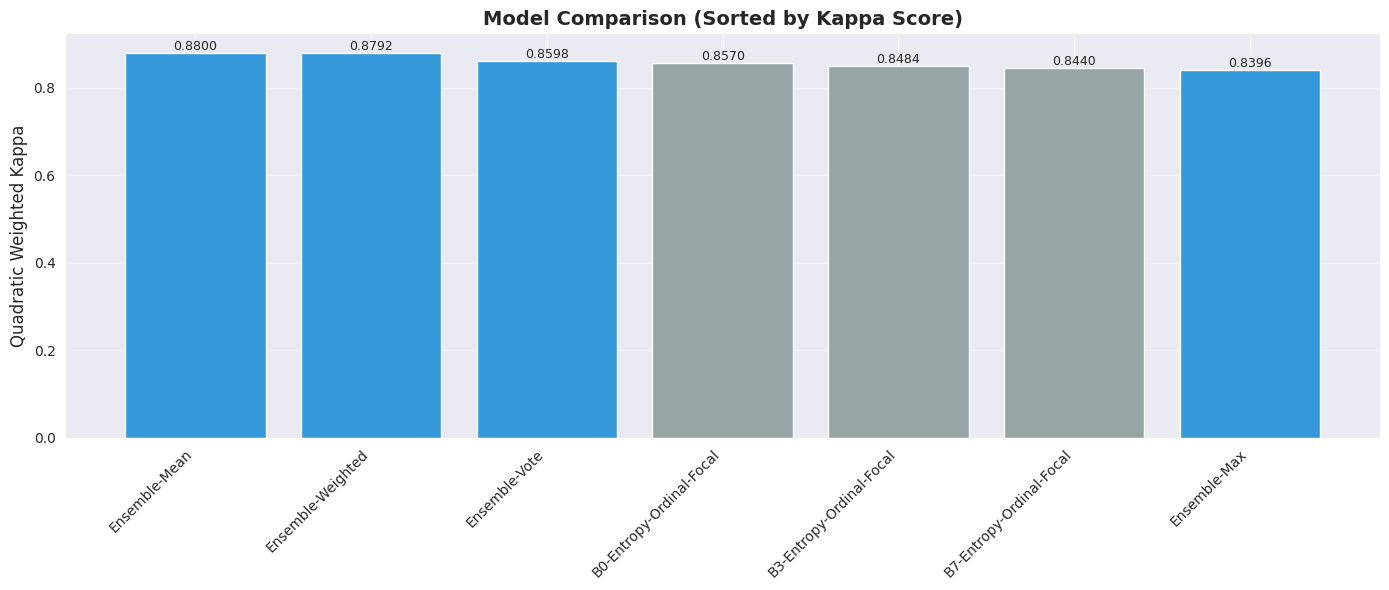

In [14]:
# Create bar plot of kappa scores
plt.figure(figsize=(14, 6))

names = [name for name, _ in sorted_results]
kappas = [metrics['kappa'] for _, metrics in sorted_results]

# Color ensemble methods differently
colors = ['#3498db' if 'Ensemble' in name else '#95a5a6' for name in names]

bars = plt.bar(range(len(names)), kappas, color=colors)
plt.xticks(range(len(names)), names, rotation=45, ha='right')
plt.ylabel('Quadratic Weighted Kappa', fontsize=12)
plt.title('Model Comparison (Sorted by Kappa Score)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add value labels on bars
for bar, kappa in zip(bars, kappas):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{kappa:.4f}',
             ha='center', va='bottom', fontsize=9)

plt.savefig('logs/ensemble-comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Confusion Matrix for Best Ensemble

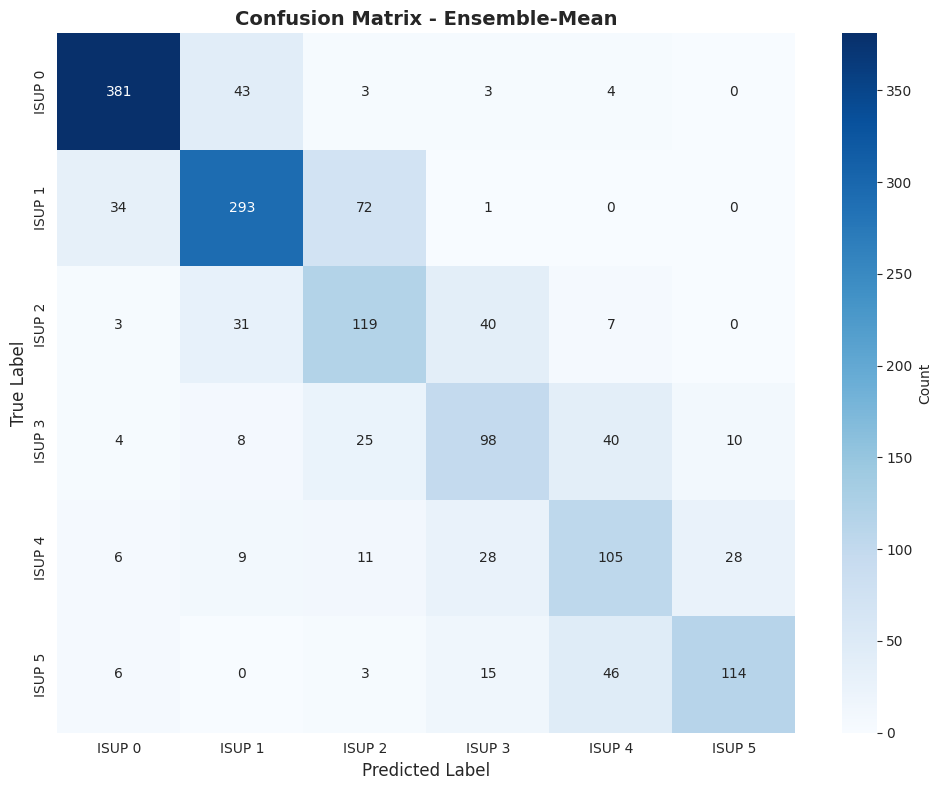

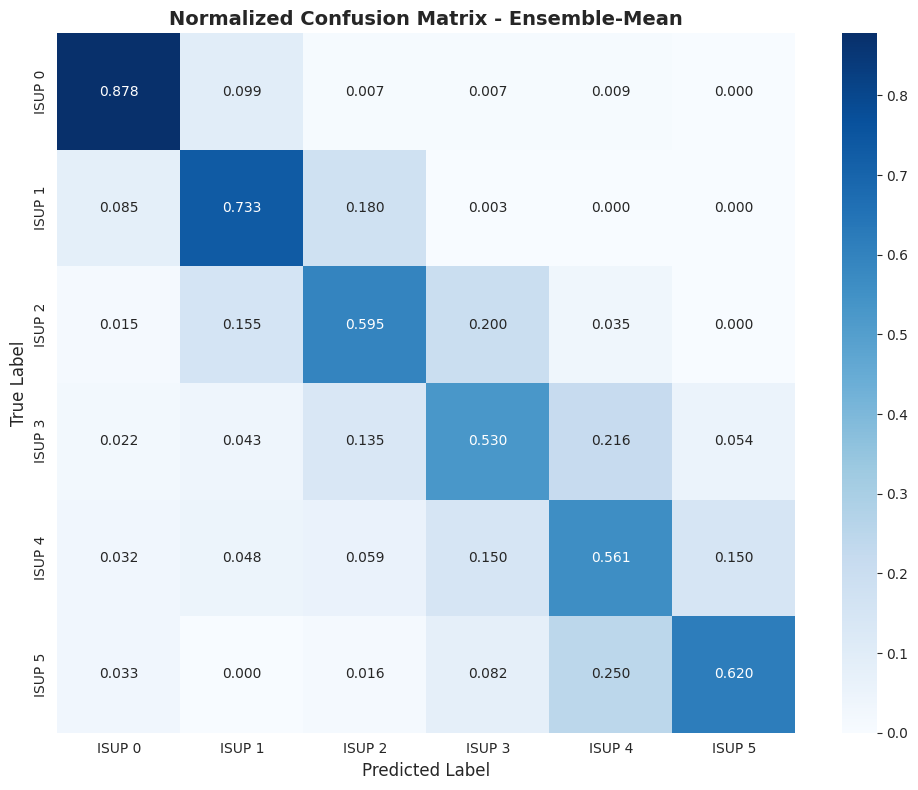

In [15]:
# Get predictions from best ensemble
best_ensemble_metrics = sorted_results[0][1]
predictions = best_ensemble_metrics['predictions']
targets = best_ensemble_metrics['targets']

# Calculate confusion matrix
cm = confusion_matrix(targets, predictions)

# Plot raw confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix - {best_model}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/ensemble-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)]
)
plt.title(f"Normalized Confusion Matrix - {best_model}", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig('logs/ensemble-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

## Classification Report

In [16]:
print(f"\nClassification Report - {best_model}")
print("="*80)
print(classification_report(
    targets, 
    predictions, 
    target_names=[f'ISUP {i}' for i in range(6)], 
    digits=4, 
    zero_division=0
))


Classification Report - Ensemble-Mean
              precision    recall  f1-score   support

      ISUP 0     0.8779    0.8779    0.8779       434
      ISUP 1     0.7630    0.7325    0.7474       400
      ISUP 2     0.5107    0.5950    0.5497       200
      ISUP 3     0.5297    0.5297    0.5297       185
      ISUP 4     0.5198    0.5615    0.5398       187
      ISUP 5     0.7500    0.6196    0.6786       184

    accuracy                         0.6981      1590
   macro avg     0.6585    0.6527    0.6539      1590
weighted avg     0.7054    0.6981    0.7005      1590



## Save Results

In [17]:
# Save detailed results to file
with open('logs/ensemble-ordinal-results.txt', 'w') as f:
    f.write("Ensemble of Ordinal Models - Test Results\n")
    f.write("="*100 + "\n\n")
    
    f.write("Models in Ensemble:\n")
    for i, name in enumerate(model_names, 1):
        f.write(f"{i}. {name}\n")
    f.write("\n")
    
    f.write("Individual Model Results:\n")
    f.write("-"*100 + "\n")
    f.write(f"{'Model':<40} {'Accuracy':>12} {'Kappa':>10} {'F1':>10} {'Recall':>10} {'Precision':>10}\n")
    f.write("-"*100 + "\n")
    
    for name, metrics in sorted_results:
        f.write(f"{name:<40} {metrics['accuracy']*100:>11.2f}% {metrics['kappa']:>10.4f} {metrics['f1']:>10.4f} {metrics['recall']:>10.4f} {metrics['precision']:>10.4f}\n")
    
    f.write("\n" + "="*100 + "\n")
    f.write(f"Best Model: {best_model} (Kappa: {best_kappa:.4f})\n")
    f.write("="*100 + "\n\n")
    
    f.write(f"Classification Report - {best_model}\n")
    f.write("-"*100 + "\n")
    f.write(classification_report(
        targets, 
        predictions, 
        target_names=[f'ISUP {i}' for i in range(6)], 
        digits=4, 
        zero_division=0
    ))
    f.write("\n\nConfusion Matrix:\n")
    f.write(str(cm))

print("\n✓ Results saved to logs/ensemble-ordinal-results.txt")


✓ Results saved to logs/ensemble-ordinal-results.txt


In [18]:
from sklearn.utils import resample
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm

def calculate_confidence_intervals(targets, predictions, n_iterations=1000, confidence=0.95):
    """
    Calcula métricas com intervalos de confiança usando bootstrapping.
    """
    metrics_stats = {
        'Accuracy': [],
        'Kappa': [],
        'F1-Score': [],
        'Recall': [],
        'Precision': []
    }

    # Loop de Bootstrap
    for _ in range(n_iterations):
        # Criar amostra de bootstrap (amostragem com reposição)
        # Mantém os índices sincronizados entre targets e predictions
        indices = resample(range(len(targets)), n_samples=len(targets))

        # Garante que trabalhamos com arrays numpy para indexação
        sample_targets = np.array(targets)[indices]
        sample_preds = np.array(predictions)[indices]

        # Calcular métricas para esta amostra
        metrics_stats['Accuracy'].append(accuracy_score(sample_targets, sample_preds))
        metrics_stats['Kappa'].append(cohen_kappa_score(sample_targets, sample_preds, weights='quadratic'))
        metrics_stats['F1-Score'].append(f1_score(sample_targets, sample_preds, average='macro', zero_division=0))
        metrics_stats['Recall'].append(recall_score(sample_targets, sample_preds, average='macro', zero_division=0))
        metrics_stats['Precision'].append(precision_score(sample_targets, sample_preds, average='macro', zero_division=0))

    # Computar estatísticas (Média, Desvio Padrão, Intervalos de Confiança)
    results = {}
    alpha = (1.0 - confidence) * 100 / 2.0

    for metric, values in metrics_stats.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        lower_ci = np.percentile(values, alpha)
        upper_ci = np.percentile(values, 100 - alpha)

        results[metric] = {
            'mean': mean_val,
            'std': std_val,
            'lower': lower_ci,
            'upper': upper_ci
        }

    return results

# ==========================================
# Executar Análise Estatística em TODOS os Modelos
# ==========================================

print("\n" + "="*100)
print("STATISTICAL ANALYSIS WITH 95% CONFIDENCE INTERVALS (ALL MODELS)")
print("="*100)

all_model_stats = []

# Iterar sobre o dicionário com todos os resultados (all_results deve ter sido definido nas células anteriores)
for model_name, metrics in all_results.items():
    print(f"\nProcessing {model_name}...")

    # Obter predições e valores reais
    preds = metrics['predictions']
    true_vals = metrics['targets']

    # Calcular Intervalos de Confiança (1000 iterações)
    stats = calculate_confidence_intervals(true_vals, preds, n_iterations=1000)

    # Armazenar para comparação final
    all_model_stats.append((model_name, stats))

    # Imprimir resultados individuais
    print(f"{'-'*40}")
    print(f"Results for {model_name}:")
    print(f"{'Metric':<15} {'Mean':<10} {'Std Dev':<10} {'95% CI (Lower)':<18} {'95% CI (Upper)':<18}")
    print("-" * 85)
    for metric, s in stats.items():
        print(f"{metric:<15} {s['mean']:.4f}     {s['std']:.4f}     {s['lower']:.4f}             {s['upper']:.4f}")

# Tabela de Resumo Comparativo (Ordenada por Kappa Médio)
print("\n" + "="*100)
print("SUMMARY COMPARISON (Sorted by Mean Kappa)")
print("="*100)
print(f"{'Model':<40} {'Kappa (Mean)':<12} {'Std Dev':<10} {'95% CI':<20}")
print("-" * 100)

# Ordenar pela média do Kappa
all_model_stats.sort(key=lambda x: x[1]['Kappa']['mean'], reverse=True)

for name, stats in all_model_stats:
    k = stats['Kappa']
    ci = f"[{k['lower']:.4f}, {k['upper']:.4f}]"
    print(f"{name:<40} {k['mean']:<12.4f} {k['std']:<10.4f} {ci:<20}")

# Salvar resultados completos em arquivo
with open('logs/all_models_stats.txt', 'w') as f:
    f.write("Full Statistical Analysis (1000 Bootstrap Iterations)\n")
    f.write("="*80 + "\n\n")
    for name, stats in all_model_stats:
        f.write(f"Model: {name}\n")
        f.write(f"{'Metric':<15} {'Mean':<10} {'Std Dev':<10} {'95% CI Lower':<15} {'95% CI Upper':<15}\n")
        for metric, s in stats.items():
            f.write(f"{metric:<15} {s['mean']:.4f}     {s['std']:.4f}     {s['lower']:.4f}          {s['upper']:.4f}\n")
        f.write("\n" + "-"*80 + "\n\n")

print("\n✓ Detailed statistics saved to logs/all_models_stats.txt")


STATISTICAL ANALYSIS WITH 95% CONFIDENCE INTERVALS (ALL MODELS)

Processing B3-Entropy-Ordinal-Focal...
----------------------------------------
Results for B3-Entropy-Ordinal-Focal:
Metric          Mean       Std Dev    95% CI (Lower)     95% CI (Upper)    
-------------------------------------------------------------------------------------
Accuracy        0.6603     0.0119     0.6384             0.6837
Kappa           0.8483     0.0121     0.8241             0.8707
F1-Score        0.6189     0.0128     0.5933             0.6453
Recall          0.6175     0.0130     0.5917             0.6440
Precision       0.6248     0.0128     0.5988             0.6505

Processing B0-Entropy-Ordinal-Focal...
----------------------------------------
Results for B0-Entropy-Ordinal-Focal:
Metric          Mean       Std Dev    95% CI (Lower)     95% CI (Upper)    
-------------------------------------------------------------------------------------
Accuracy        0.6602     0.0120     0.6358         

## Summary

This notebook created and evaluated an ensemble of four ordinal models:

1. **B0 Entropy-Ordinal**: Base model with entropy filtering and ordinal loss
2. **B0 Entropy-Ordinal-Focal**: Adds focal loss to handle class imbalance
3. **B0 Entropy-Ordinal-Weighted**: Uses class-weighted loss
4. **B7 Entropy-Ordinal-Focal**: Larger EfficientNet-B7 backbone with focal loss

### Ensemble Methods Tested:

- **Mean**: Simple average of predicted probabilities
- **Weighted Mean**: Weighted average giving more importance to focal and B7 models
- **Max**: Maximum probability across models
- **Majority Vote**: Hard voting on predicted classes

### Key Findings:

The results show which ensemble method performs best for combining these ordinal models. Ensemble methods typically improve robustness and generalization by combining the strengths of different models trained with different loss functions and architectures.